In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [7]:
# change working directory
os.chdir(r"/Users/f/downloads")

# define data csv to be read
df = pd.read_csv('Unit02 auto-mpg.csv')

In [8]:
# data exploration to see if any null values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [10]:
# further data exploration to see if any null values 
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [11]:
df.head

<bound method NDFrame.head of       mpg  cylinders  displacement horsepower  weight  acceleration  \
0    18.0          8         307.0        130    3504          12.0   
1    15.0          8         350.0        165    3693          11.5   
2    18.0          8         318.0        150    3436          11.0   
3    16.0          8         304.0        150    3433          12.0   
4    17.0          8         302.0        140    3449          10.5   
..    ...        ...           ...        ...     ...           ...   
393  27.0          4         140.0         86    2790          15.6   
394  44.0          4          97.0         52    2130          24.6   
395  32.0          4         135.0         84    2295          11.6   
396  28.0          4         120.0         79    2625          18.6   
397  31.0          4         119.0         82    2720          19.4   

     model year  origin                   car name  
0            70       1  chevrolet chevelle malibu  
1          

In [12]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [13]:
df.shape

(398, 9)

In [16]:
# Estimate skewness and kurtosis
df.select_dtypes(include='number').skew(), df.select_dtypes(include='number').kurt()

(mpg             0.457066
 cylinders       0.526922
 displacement    0.719645
 weight          0.531063
 acceleration    0.278777
 model year      0.011535
 origin          0.923776
 dtype: float64,
 mpg            -0.510781
 cylinders      -1.376662
 displacement   -0.746597
 weight         -0.785529
 acceleration    0.419497
 model year     -1.181232
 origin         -0.817597
 dtype: float64)

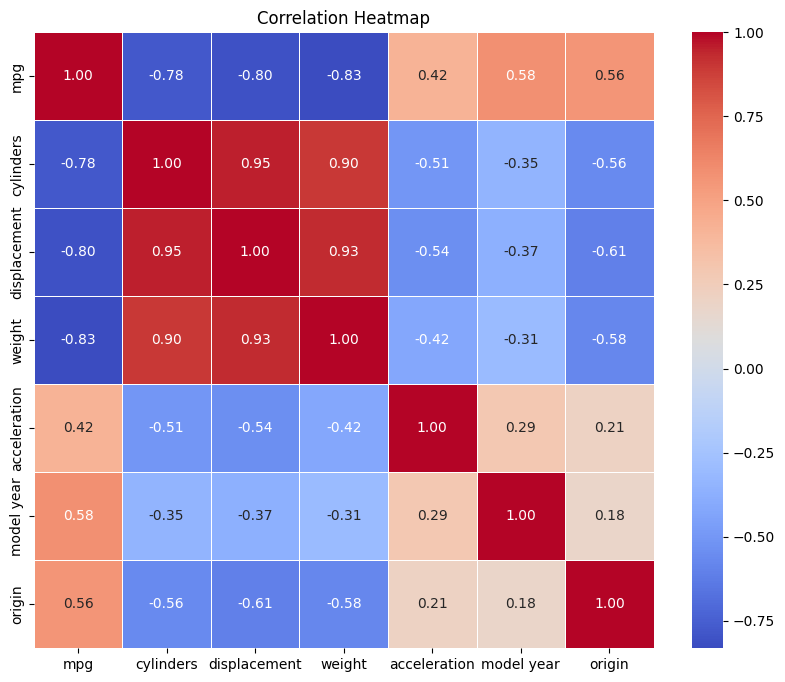

In [21]:
# Correlation heatmap
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,        # Show correlation values
            cmap='coolwarm',   # Color scheme
            fmt=".2f",         # Format to 2 decimal places
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

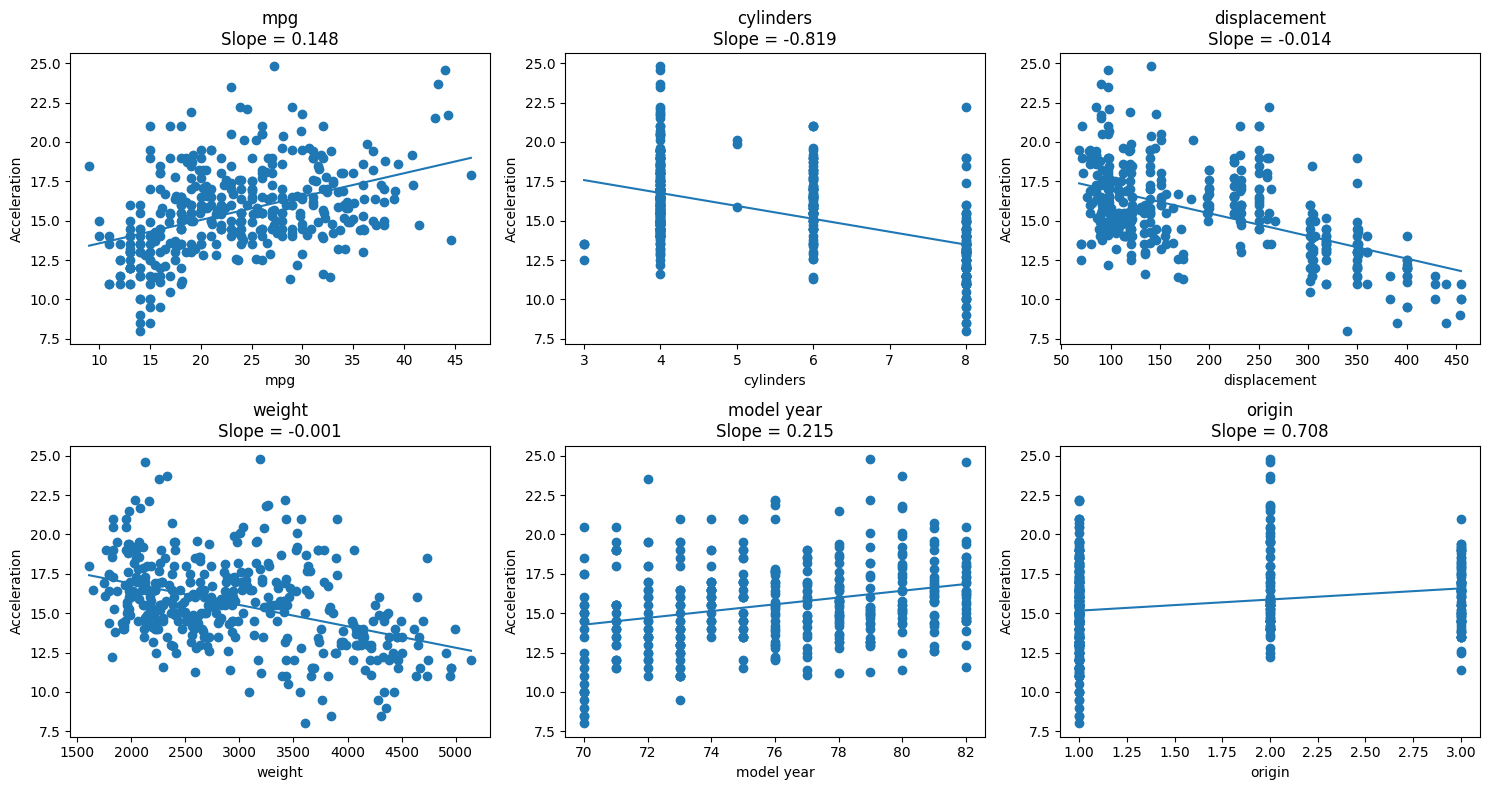

In [27]:
# Scatter plot for different parameters.
from sklearn.preprocessing import StandardScaler

predictors = [
    'mpg', 'cylinders', 'displacement', 
    'weight', 'model year', 'origin'
]

y = df['acceleration'].values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(predictors):

    x = df[var].values

    # Remove missing values
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]

    # Fit regression line
    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    # Sort values for smooth line
    sorted_idx = np.argsort(x_clean)
    x_sorted = x_clean[sorted_idx]
    y_fit_sorted = slope * x_sorted + intercept

    # Plot
    axes[i].scatter(x_clean, y_clean)
    axes[i].plot(x_sorted, y_fit_sorted)
    axes[i].set_title(f'{var}\nSlope = {slope:.3f}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Acceleration')

plt.tight_layout()
plt.show()

In [28]:
# Replace categorical values with numerical values (in this case car name column)
# check numbner of unique car names 
df['car name'].nunique()

305

In [29]:
# based on large number of car name variations will group based on brand, first create the brand split
df['brand'] = df['car name'].str.split().str[0]

# check numbner of unique car brandds
df['brand'].nunique()

37

In [30]:
# one hot encode the car brand 
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

In [31]:
df.shape

(398, 45)

In [34]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,brand_audi,...,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_toyouta,brand_triumph,brand_vokswagen,brand_volkswagen,brand_volvo,brand_vw
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,False,...,False,False,False,False,False,False,False,False,False,False
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,False,...,False,False,False,False,False,False,False,False,False,False
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,False,...,False,False,False,False,False,False,False,False,False,False
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,False,...,False,False,False,False,False,False,False,False,False,False
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,False,...,False,False,False,False,False,False,False,False,False,False
